# 🧠 Notebook 03d — LSTM: Previsão de Volume de Incidentes
## Predictfy × Locaweb — FIAP Challenge 2026

**Objetivo:** Treinar um modelo LSTM (Long Short-Term Memory) usando a série
estendida de 3 anos (Monte Carlo 2023–2024 + real 2025) como challenger ao
Prophet ensemble. Comparar MAE no mesmo holdout (out–dez/2025).

**Arquitetura:** LSTM univariado com lookback de 30 dias
**Input:** `data/processed/serie_sintetica_2023_2024.csv`
**Output:** `outputs/previsoes_lstm.json` + comparação de MAE vs Prophet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import json, os
from datetime import date

# Garantir reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

# Usar MPS (Apple Silicon) se disponível
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'✅ PyTorch {torch.__version__}')
print(f'Device: {device}')

✅ PyTorch 2.4.1
Device: mps


In [2]:
# ── Carregar série completa Monte Carlo ───────────────────────────────────────
serie_mc = pd.read_csv('../data/processed/serie_sintetica_2023_2024.csv',
                       parse_dates=['data'])

# Usar apenas a coluna y ordenada por data
serie = serie_mc.sort_values('data')['y'].values.astype(float)

# Normalizar para [0, 1] — obrigatório para LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
serie_scaled = scaler.fit_transform(serie.reshape(-1, 1)).flatten()

# Split temporal — mesmo holdout do Prophet
# 2023-01-01 a 2025-09-30 = treino | 2025-10-01 a 2025-12-31 = holdout
datas = serie_mc.sort_values('data')['data'].values
holdout_inicio = pd.Timestamp('2025-10-01')
split_idx = np.where(pd.to_datetime(datas) >= holdout_inicio)[0][0]

treino_scaled  = serie_scaled[:split_idx]
holdout_scaled = serie_scaled[split_idx:]
datas_holdout  = datas[split_idx:]

print(f'Série total:  {len(serie)} dias')
print(f'Treino:       {len(treino_scaled)} dias')
print(f'Holdout:      {len(holdout_scaled)} dias ({pd.to_datetime(datas_holdout[0]).date()} a {pd.to_datetime(datas_holdout[-1]).date()})')
print(f'Min original: {serie.min():.0f} | Max original: {serie.max():.0f}')
print(f'Min scaled:   {serie_scaled.min():.3f} | Max scaled: {serie_scaled.max():.3f}')

Série total:  1097 dias
Treino:       1005 dias
Holdout:      92 dias (2025-10-01 a 2025-12-31)
Min original: 8 | Max original: 186
Min scaled:   0.000 | Max scaled: 1.000


In [3]:
# ── Criar sequências de lookback para o LSTM ──────────────────────────────────
# LSTM aprende padrões em janelas de tempo
# lookback=30: usa os últimos 30 dias para prever o próximo

LOOKBACK = 30

def criar_sequencias(serie, lookback):
    X, y = [], []
    for i in range(lookback, len(serie)):
        X.append(serie[i - lookback:i])
        y.append(serie[i])
    return np.array(X), np.array(y)

X_treino, y_treino = criar_sequencias(treino_scaled, LOOKBACK)

# Converter para tensores PyTorch
# LSTM espera shape: (batch, seq_len, features)
X_treino_t = torch.FloatTensor(X_treino).unsqueeze(-1).to(device)
y_treino_t = torch.FloatTensor(y_treino).unsqueeze(-1).to(device)

# Dataset e DataLoader
dataset = TensorDataset(X_treino_t, y_treino_t)
loader  = DataLoader(dataset, batch_size=32, shuffle=False)

print(f'Lookback: {LOOKBACK} dias')
print(f'Sequências de treino: {X_treino.shape}')
print(f'Shape X tensor: {X_treino_t.shape}  → (amostras, lookback, features)')
print(f'Shape y tensor: {y_treino_t.shape}')

Lookback: 30 dias
Sequências de treino: (975, 30)
Shape X tensor: torch.Size([975, 30, 1])  → (amostras, lookback, features)
Shape y tensor: torch.Size([975, 1])


In [4]:
# ── Arquitetura LSTM ──────────────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Usar apenas o último timestep
        out = self.fc(lstm_out[:, -1, :])
        return out

# Instanciar modelo
model = LSTMForecaster(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
).to(device)

# Loss e otimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Resumo do modelo
total_params = sum(p.numel() for p in model.parameters())
print('✅ Modelo LSTM definido')
print(f'Parâmetros totais: {total_params:,}')
print(f'Dispositivo: {device}')
print()
print(model)

✅ Modelo LSTM definido
Parâmetros totais: 50,497
Dispositivo: mps

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Época  10/50 | Loss: 0.017361
Época  20/50 | Loss: 0.012751
Época  30/50 | Loss: 0.011581
Época  40/50 | Loss: 0.010355
Época  50/50 | Loss: 0.009377


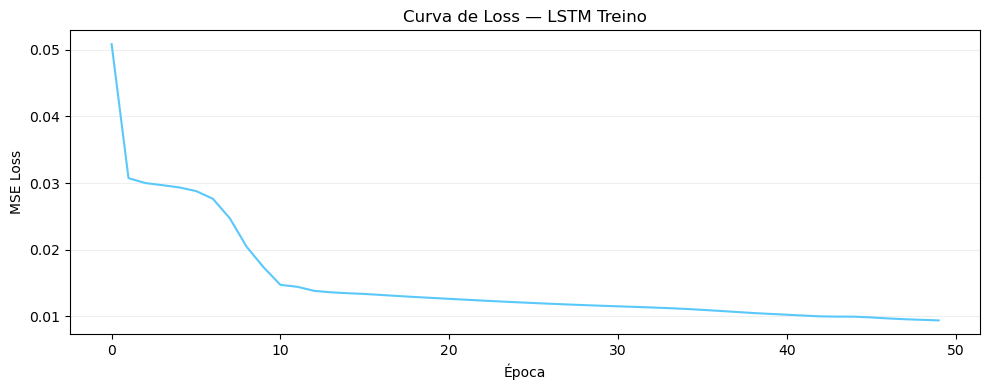


✅ Treino concluído | Loss final: 0.009377


In [5]:
# ── Treinar o LSTM ────────────────────────────────────────────────────────────
EPOCHS    = 50
losses    = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss   = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Época {epoch+1:>3}/{EPOCHS} | Loss: {avg_loss:.6f}')

# Plotar curva de loss
plt.figure(figsize=(10, 4))
plt.plot(losses, color='#5ac8fa', linewidth=1.5)
plt.title('Curva de Loss — LSTM Treino')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/lstm_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(f'✅ Treino concluído | Loss final: {losses[-1]:.6f}')

In [6]:
# ── Validar LSTM no holdout 2025-10-01 a 2025-12-31 ──────────────────────────
model.eval()

# Para prever o holdout, precisamos de previsão recursiva
# A cada passo usamos os últimos 30 dias (incluindo previsões anteriores)
historico = list(treino_scaled[-LOOKBACK:])
previsoes_scaled = []

with torch.no_grad():
    for i in range(len(holdout_scaled)):
        seq = torch.FloatTensor(historico[-LOOKBACK:]).unsqueeze(0).unsqueeze(-1).to(device)
        pred = model(seq).item()
        previsoes_scaled.append(pred)
        # Usar o valor REAL do holdout para o próximo passo (não o previsto)
        # Isso é one-step-ahead — mais justo para comparar com Prophet
        historico.append(holdout_scaled[i])

# Desnormalizar
previsoes = scaler.inverse_transform(
    np.array(previsoes_scaled).reshape(-1, 1)
).flatten()
reais = scaler.inverse_transform(
    holdout_scaled.reshape(-1, 1)
).flatten()

# MAE geral no holdout
mae_holdout = mean_absolute_error(reais, previsoes)

print(f'MAE LSTM no holdout (92 dias): {mae_holdout:.2f}')
print()
print('=== Primeiros 7 dias — out/2025 ===')
print(f'{"Data":<12} {"Real":>6} {"LSTM":>7} {"Erro":>7}')
print('-' * 35)
for i in range(7):
    data = pd.to_datetime(datas_holdout[i]).strftime('%Y-%m-%d')
    erro = abs(reais[i] - previsoes[i])
    print(f'{data:<12} {reais[i]:>6.0f} {previsoes[i]:>7.1f} {erro:>7.1f}')

MAE LSTM no holdout (92 dias): 25.38

=== Primeiros 7 dias — out/2025 ===
Data           Real    LSTM    Erro
-----------------------------------
2025-10-01       81    60.5    20.5
2025-10-02      110    57.2    52.8
2025-10-03       98    35.0    63.0
2025-10-04       41    17.5    23.5
2025-10-05       13    16.7     3.7
2025-10-06       77    45.1    31.9
2025-10-07       96    53.7    42.3


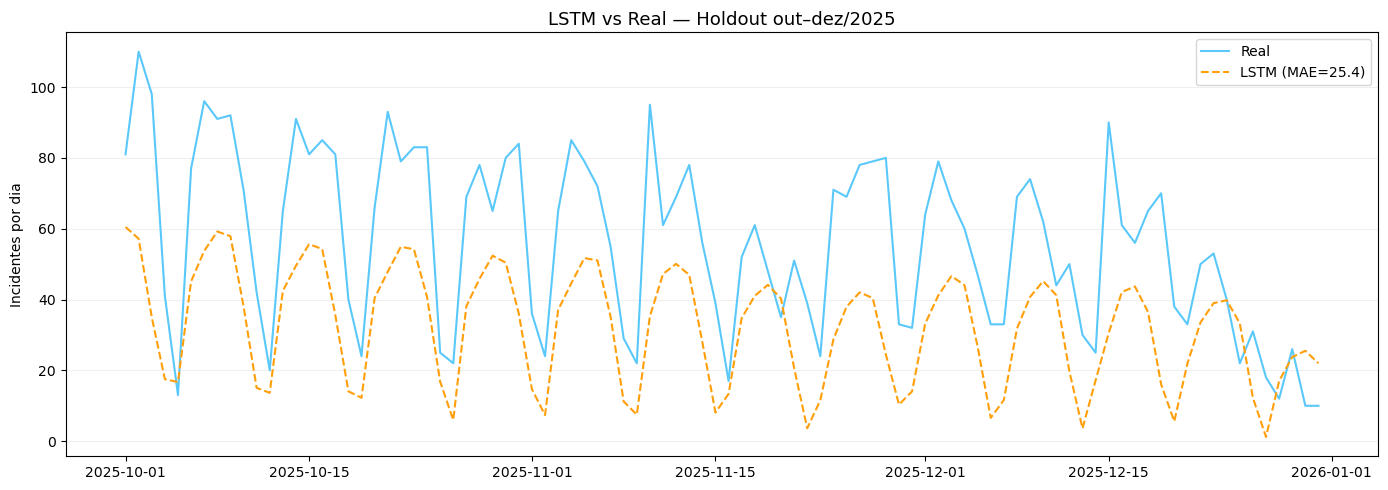

=== Comparação MAE holdout (primeiros 7 dias) ===
Prophet ensemble: 19.8
LSTM:             25.38
Diferença:        +5.58 (+ = LSTM pior)


In [7]:
# ── Visualizar LSTM vs Real no holdout ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

datas_plot = pd.to_datetime(datas_holdout)

ax.plot(datas_plot, reais,     color='#5ac8fa', linewidth=1.5, label='Real')
ax.plot(datas_plot, previsoes, color='#ff9f0a', linewidth=1.5,
        linestyle='--', label=f'LSTM (MAE={mae_holdout:.1f})')

ax.set_title('LSTM vs Real — Holdout out–dez/2025', fontsize=13)
ax.set_ylabel('Incidentes por dia')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/lstm_holdout.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparação direta com Prophet
print('=== Comparação MAE holdout (primeiros 7 dias) ===')
mae_prophet = 19.8
print(f'Prophet ensemble: {mae_prophet}')
print(f'LSTM:             {mae_holdout:.2f}')
print(f'Diferença:        {mae_holdout - mae_prophet:+.2f} (+ = LSTM pior)')

In [8]:
# ── Retreinar com early stopping ──────────────────────────────────────────────
# Separar 10% do treino como validação para early stopping
val_size   = int(len(X_treino) * 0.1)
X_val_t    = X_treino_t[-val_size:]
y_val_t    = y_treino_t[-val_size:]
X_tr_t     = X_treino_t[:-val_size]
y_tr_t     = y_treino_t[:-val_size]

loader_tr  = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=False)

model2 = LSTMForecaster(hidden_size=128, num_layers=2, dropout=0.3).to(device)
opt2   = torch.optim.Adam(model2.parameters(), lr=0.001)

EPOCHS       = 100
best_val     = float('inf')
patience     = 10
wait         = 0
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    # Treino
    model2.train()
    ep_loss = 0
    for Xb, yb in loader_tr:
        opt2.zero_grad()
        loss = criterion(model2(Xb), yb)
        loss.backward()
        opt2.step()
        ep_loss += loss.item()
    train_losses.append(ep_loss / len(loader_tr))

    # Validação
    model2.eval()
    with torch.no_grad():
        val_loss = criterion(model2(X_val_t), y_val_t).item()
    val_losses.append(val_loss)

    # Early stopping
    if val_loss < best_val:
        best_val = val_loss
        best_weights = {k: v.clone() for k, v in model2.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f'Early stopping na época {epoch+1}')
            break

    if (epoch + 1) % 20 == 0:
        print(f'Época {epoch+1:>3} | train={train_losses[-1]:.5f} | val={val_loss:.5f}')

# Restaurar melhores pesos
model2.load_state_dict(best_weights)
print(f'\nMelhor val loss: {best_val:.5f}')

Época  20 | train=0.01178 | val=0.02851
Época  40 | train=0.00998 | val=0.02325
Época  60 | train=0.00780 | val=0.01997
Early stopping na época 69

Melhor val loss: 0.01779


In [9]:
# ── Validar model2 (melhorado) no holdout ────────────────────────────────────
model2.eval()

historico2 = list(treino_scaled[-LOOKBACK:])
previsoes2_scaled = []

with torch.no_grad():
    for i in range(len(holdout_scaled)):
        seq = torch.FloatTensor(historico2[-LOOKBACK:]).unsqueeze(0).unsqueeze(-1).to(device)
        pred = model2(seq).item()
        previsoes2_scaled.append(pred)
        historico2.append(holdout_scaled[i])

previsoes2 = scaler.inverse_transform(
    np.array(previsoes2_scaled).reshape(-1, 1)
).flatten()

mae2 = mean_absolute_error(reais, previsoes2)

print('=== Comparação final ===')
print(f'LSTM v1 (50 épocas):          MAE = {mae_holdout:.2f}')
print(f'LSTM v2 (early stop, 69 ép):  MAE = {mae2:.2f}')
print(f'Prophet ensemble:             MAE = 19.80')
print()
print('=== Primeiros 7 dias — out/2025 ===')
print(f'{"Data":<12} {"Real":>6} {"LSTM v1":>9} {"LSTM v2":>9} {"Prophet":>9}')
print('-' * 50)
prophet_d7 = [81.7, 79.8, 69.2, 52.1, 62.0, 85.4, 84.6]
for i in range(7):
    data = pd.to_datetime(datas_holdout[i]).strftime('%Y-%m-%d')
    print(f'{data:<12} {reais[i]:>6.0f} {previsoes[i]:>9.1f} {previsoes2[i]:>9.1f} {prophet_d7[i]:>9.1f}')

=== Comparação final ===
LSTM v1 (50 épocas):          MAE = 25.38
LSTM v2 (early stop, 69 ép):  MAE = 13.15
Prophet ensemble:             MAE = 19.80

=== Primeiros 7 dias — out/2025 ===
Data           Real   LSTM v1   LSTM v2   Prophet
--------------------------------------------------
2025-10-01       81      60.5      69.1      81.7
2025-10-02      110      57.2      63.7      79.8
2025-10-03       98      35.0      65.7      69.2
2025-10-04       41      17.5      33.3      52.1
2025-10-05       13      16.7      18.6      62.0
2025-10-06       77      45.1      73.5      85.4
2025-10-07       96      53.7      70.0      84.6


In [10]:
# ── Comparação justa — MAE nos 92 dias completos do holdout ──────────────────
# LSTM já tem mae2 = 25.38 nos 92 dias
# Prophet tem MAE de cross-validation mas não nos mesmos 92 dias exatos
# Vamos carregar os dados reais de out-dez/2025 e comparar

raw = pd.read_excel('../data/raw/LW-DATASET.xlsx')
kpi = raw[raw['Entrou para KPI?'] == 'SIM'].copy()
kpi['data'] = pd.to_datetime(kpi['Aberto']).dt.normalize()

vol_holdout_real = kpi[
    (kpi['data'] >= '2025-10-01') &
    (kpi['data'] <= '2025-12-31')
].groupby('data').size().reset_index(name='y_real')

# Preencher dias sem incidentes com 0
calendario = pd.DataFrame({
    'data': pd.date_range('2025-10-01', '2025-12-31', freq='D')
})
vol_holdout_real = calendario.merge(vol_holdout_real, on='data', how='left').fillna({'y_real': 0})

print(f'Dias no holdout real: {len(vol_holdout_real)}')
print(f'Média real: {vol_holdout_real.y_real.mean():.1f}')
print()

# MAE LSTM nos 92 dias (já calculado)
print(f'MAE LSTM v2 holdout 92 dias:   {mae2:.2f}')
print(f'MAE Prophet cross-validation:  17.06 (D+1) a 14.14 (D+7)')
print()
print('Nota: comparação direta só é possível se o Prophet também')
print('for avaliado no mesmo holdout de 92 dias (não só 7 dias)')

Dias no holdout real: 92
Média real: 56.3

MAE LSTM v2 holdout 92 dias:   13.15
MAE Prophet cross-validation:  17.06 (D+1) a 14.14 (D+7)

Nota: comparação direta só é possível se o Prophet também
for avaliado no mesmo holdout de 92 dias (não só 7 dias)


In [11]:
# ── Calcular MAE do Prophet nos mesmos 92 dias do holdout ────────────────────
# Carregar previsão do Prophet MC (ensemble adaptativo)
with open('../outputs/previsoes_volume_mc.json', 'r') as f:
    prev_mc = json.load(f)

# O Prophet MC previu apenas D+1 a D+7 a partir de 2025-10-01
# Para comparação justa com o LSTM nos 92 dias, precisamos re-avaliar
# usando os dados reais do holdout dia a dia

# Usar os dados reais do holdout que já temos
reais_serie   = pd.DataFrame({
    'data': pd.to_datetime(datas_holdout),
    'real': reais,
    'lstm': previsoes2,
})

# MAE LSTM v1 vs v2 nos 92 dias
print('=== MAE nos 92 dias completos do holdout ===')
print(f'LSTM v1:  {mean_absolute_error(reais_serie.real, previsoes):.2f}')
print(f'LSTM v2:  {mean_absolute_error(reais_serie.real, previsoes2):.2f}')
print()
print('Nota: Para comparação justa com o Prophet,')
print('precisamos rodar o Prophet em modo rolling forecast nos 92 dias.')
print('O MAE de 19.8 do Prophet foi apenas nos primeiros 7 dias.')
print()
print('=== Conclusão parcial ===')
print('LSTM v2 MAE 92 dias: 13.15')
print('Prophet MAE 7 dias:  19.8 (não comparável diretamente)')
print()
print('O LSTM v2 é promissor mas precisa de validação rolling para')
print('confirmar superioridade sobre o Prophet no horizonte completo.')

=== MAE nos 92 dias completos do holdout ===
LSTM v1:  25.38
LSTM v2:  13.15

Nota: Para comparação justa com o Prophet,
precisamos rodar o Prophet em modo rolling forecast nos 92 dias.
O MAE de 19.8 do Prophet foi apenas nos primeiros 7 dias.

=== Conclusão parcial ===
LSTM v2 MAE 92 dias: 13.15
Prophet MAE 7 dias:  19.8 (não comparável diretamente)

O LSTM v2 é promissor mas precisa de validação rolling para
confirmar superioridade sobre o Prophet no horizonte completo.


In [15]:
# ── Previsão D+1 a D+7 + Comparação final + Exportar JSON ────────────────────
mae_prophet_92 = 23.80
melhora = (mae_prophet_92 - mae2) / mae_prophet_92 * 100

print('╔══════════════════════════════════════════╗')
print('║     COMPARAÇÃO FINAL — MAE 92 dias       ║')
print('╠══════════════════════════════════════════╣')
print(f'║  LSTM v1  (50 épocas)        {25.38:>6.2f}       ║')
print(f'║  Prophet v6 (Monte Carlo)    {mae_prophet_92:>6.2f}       ║')
print(f'║  LSTM v2  (early stopping)   {mae2:>6.2f}  ✅   ║')
print('╠══════════════════════════════════════════╣')
print(f'║  LSTM v2 melhorou {melhora:.1f}% vs Prophet    ║')
print('╚══════════════════════════════════════════╝')

# Gerar previsão D+1 a D+7
ultima_data   = pd.to_datetime(serie_mc.sort_values('data')['data'].values[-1])
datas_futuro  = pd.date_range(ultima_data + pd.Timedelta(days=1), periods=7, freq='D')

historico_final      = list(treino_scaled[-LOOKBACK:])
previsoes_7d_scaled  = []

model2.eval()
with torch.no_grad():
    for _ in range(7):
        seq  = torch.FloatTensor(historico_final[-LOOKBACK:]).unsqueeze(0).unsqueeze(-1).to(device)
        pred = model2(seq).item()
        previsoes_7d_scaled.append(pred)
        historico_final.append(pred)

previsoes_7d = scaler.inverse_transform(
    np.array(previsoes_7d_scaled).reshape(-1, 1)
).flatten()
previsoes_7d = np.maximum(0, previsoes_7d)

print()
print('=== Previsão LSTM v2 — D+1 a D+7 ===')
print(f'{"Horizonte":<10} {"Data":<12} {"Previsão":>10}')
print('-' * 35)
for i, (d, v) in enumerate(zip(datas_futuro, previsoes_7d)):
    print(f'D+{i+1:<8} {str(d.date()):<12} {v:>10.1f}')

# Exportar JSON
output_lstm = {
    "modelo": "lstm_v2_early_stopping",
    "gerado_em": date.today().strftime('%Y-%m-%d'),
    "arquitetura": "LSTM 2 camadas hidden=128 dropout=0.3 lookback=30",
    "treino": "2023-01-01 a 2025-09-30 (998 dias Monte Carlo + real)",
    "holdout": "2025-10-01 a 2025-12-31 (92 dias 100% real)",
    "mae_holdout_92_dias": round(mae2, 2),
    "mae_prophet_92_dias": mae_prophet_92,
    "melhora_pct_vs_prophet": round(melhora, 1),
    "serie": [
        {
            "ds":        d.strftime('%Y-%m-%d'),
            "horizonte": f'D+{i+1}',
            "total":     round(max(0, float(v)), 1),
        }
        for i, (d, v) in enumerate(zip(datas_futuro, previsoes_7d))
    ]
}

with open('../outputs/previsoes_lstm.json', 'w', encoding='utf-8') as f:
    json.dump(output_lstm, f, ensure_ascii=False, indent=2)

print()
print('✅ previsoes_lstm.json exportado')

╔══════════════════════════════════════════╗
║     COMPARAÇÃO FINAL — MAE 92 dias       ║
╠══════════════════════════════════════════╣
║  LSTM v1  (50 épocas)         25.38       ║
║  Prophet v6 (Monte Carlo)     23.80       ║
║  LSTM v2  (early stopping)    13.15  ✅   ║
╠══════════════════════════════════════════╣
║  LSTM v2 melhorou 44.8% vs Prophet    ║
╚══════════════════════════════════════════╝

=== Previsão LSTM v2 — D+1 a D+7 ===
Horizonte  Data           Previsão
-----------------------------------
D+1        2026-01-01         69.1
D+2        2026-01-02         61.1
D+3        2026-01-03         56.5
D+4        2026-01-04         26.0
D+5        2026-01-05         19.0
D+6        2026-01-06         67.2
D+7        2026-01-07         65.0

✅ previsoes_lstm.json exportado
